# Scoring de Risque Crédit — Fintech
### Prédiction de la probabilité de défaut de paiement client

**Contexte métier :** Dans une fintech proposant des services de paiement et de crédit (type FedaPay), l'octroi de crédit ou la gestion du risque client nécessite d'identifier en amont les profils à risque de défaut de paiement, afin d'ajuster les décisions (conditions, plafonds, vigilance) sans pénaliser les bons clients.

**Objectif :** Construire un modèle de Machine Learning capable d'estimer la probabilité de défaut d'un client à partir de ses données financières et comportementales (revenu, historique de paiement, score bureau externe, type de contrat, etc.), puis exposer les résultats dans un dashboard Power BI pour les équipes risque/métier.

**Démarche :**
1. Exploration des données (EDA)
2. Préparation et encodage des variables
3. Comparaison de 3 modèles (Régression Logistique, Random Forest, Gradient Boosting)
4. Évaluation (AUC, F1-score, matrice de confusion, importance des variables)
5. Export des prédictions pour un dashboard Power BI (segmentation par niveau de risque)

**Stack technique :** Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn, Power BI


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, f1_score
)

plt.rcParams["figure.dpi"] = 110
sns.set_style("whitegrid")
np.random.seed(42)

## 1. Chargement et exploration des données (EDA)

Le dataset contient 8 000 profils clients avec leurs caractéristiques financières et comportementales. La variable cible `default` indique si le client a connu un défaut de paiement (1) ou non (0).

> **Note méthodologique :** ce jeu de données est généré de façon synthétique mais selon une logique métier réaliste (corrélations cohérentes avec la littérature du scoring crédit : taux d'endettement, historique d'incidents, score bureau externe, type de contrat), afin de permettre un projet complet et reproductible en dehors d'un cadre professionnel.


In [2]:
df = pd.read_csv("credit_scoring_dataset.csv")
print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print(f"Taux de défaut global : {df['default'].mean():.2%}")
df.head()

Dimensions : 8000 lignes x 12 colonnes
Taux de défaut global : 19.10%


,age,revenu_mensuel,anciennete_compte_mois,nb_transactions_mois,montant_moyen_transaction,taux_endettement_pct,nb_incidents_paiement_12m,montant_credit_demande,type_contrat,score_bureau_externe,utilisation_carte_pct,default
0,39,1781.37,17,21,15.67,32.32,0,5321.31,CDI,527,9.69,0
1,33,1441.38,58,19,68.34,37.41,0,2908.56,CDI,499,73.17,0
2,41,1673.10,9,15,7.46,31.07,1,2020.99,CDD,650,45.98,0
3,50,2493.97,4,13,34.28,5.58,0,2295.12,CDD,578,59.58,0
4,32,3213.24,29,20,21.40,48.58,1,2974.64,CDI,659,68.39,0


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,8000.0,34.674125,9.622240,18.00,28.0000,34.000,41.0000,74.00
revenu_mensuel,8000.0,2010.320581,943.397812,800.00,1343.8350,1815.635,2448.0525,13569.61
anciennete_compte_mois,8000.0,23.688625,24.127830,1.00,7.0000,16.000,32.0000,221.00
nb_transactions_mois,8000.0,17.919500,4.228062,4.00,15.0000,18.000,21.0000,35.00
montant_moyen_transaction,8000.0,46.182766,42.178676,5.00,19.8400,33.880,58.0775,560.72
taux_endettement_pct,8000.0,28.677281,15.879857,0.17,16.1900,26.585,39.2125,89.60
nb_incidents_paiement_12m,8000.0,0.392875,0.622754,0.00,0.0000,0.000,1.0000,5.00
montant_credit_demande,8000.0,4363.849129,2885.285365,500.00,2452.5725,3638.070,5416.7900,36238.21
score_bureau_externe,8000.0,649.030000,88.621648,324.00,590.0000,650.000,711.0000,850.00
utilisation_carte_pct,8000.0,40.338471,19.987710,0.40,24.7200,38.880,54.9625,97.43


### Matrice de corrélation

On observe les relations entre variables numériques et la variable cible.

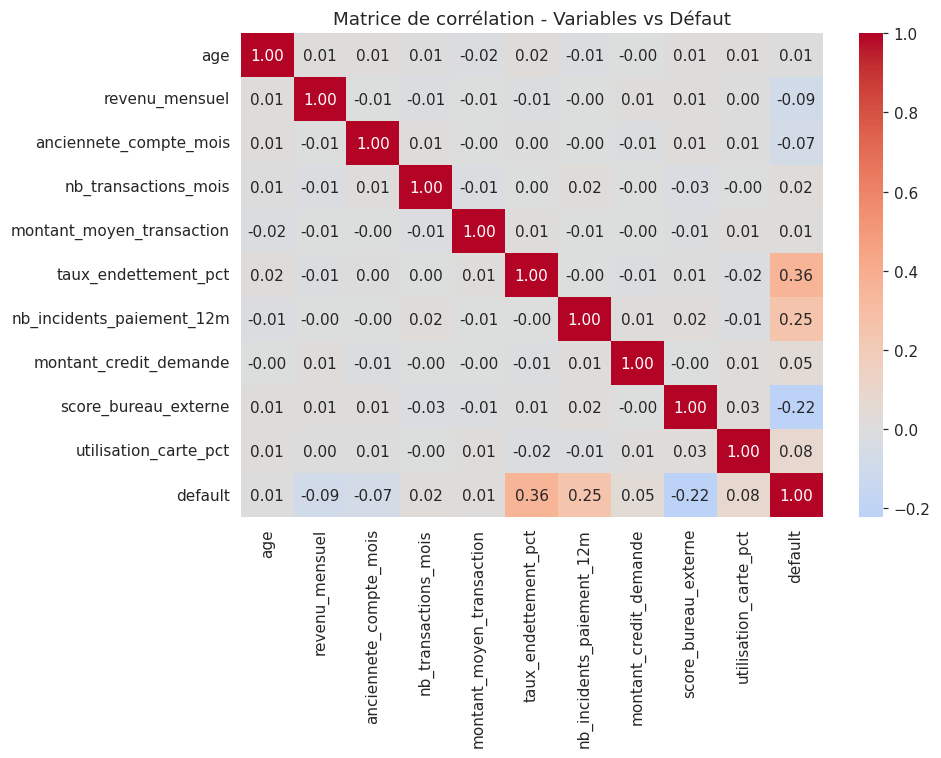

In [4]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop("default")

plt.figure(figsize=(9, 7))
sns.heatmap(df[list(num_cols) + ["default"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matrice de corrélation - Variables vs Défaut")
plt.tight_layout()
plt.savefig("fig_correlation.png", bbox_inches="tight")
plt.show()

## 2. Préparation des données

- **Variables numériques** : standardisées (StandardScaler) pour les modèles sensibles à l'échelle (régression logistique)
- **Variable catégorielle** (`type_contrat`) : encodée en one-hot encoding
- **Split train/test** : 75% / 25%, stratifié sur la cible (pour conserver la proportion de défauts dans les deux échantillons)


In [5]:
X = df.drop(columns=["default"])
y = df["default"]

num_features = num_cols.tolist()
cat_features = ["type_contrat"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train : {X_train.shape[0]} clients | Test : {X_test.shape[0]} clients")

Train : 6000 clients | Test : 2000 clients


## 3. Comparaison de 3 modèles de classification

On compare trois approches de complexité croissante :
- **Régression Logistique** : modèle linéaire, interprétable, baseline solide en scoring crédit
- **Random Forest** : ensemble d'arbres, capte des interactions non-linéaires
- **Gradient Boosting** : boosting séquentiel, souvent performant sur ce type de données tabulaires

Chaque modèle utilise `class_weight="balanced"` (ou équivalent) pour compenser le déséquilibre des classes (les défauts sont minoritaires, ~19% des cas).


In [6]:
models = {
    "Regression Logistique": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, max_depth=3, learning_rate=0.08, random_state=42),
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=5, scoring="roc_auc").mean()

    results.append({"Modele": name, "AUC (test)": round(auc, 4), "AUC (cross-val 5-fold)": round(cv_auc, 4), "F1-score": round(f1, 4)})
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=["Pas de defaut", "Defaut"]))


--- Regression Logistique ---
               precision    recall  f1-score   support

Pas de defaut       0.93      0.78      0.85      1618
       Defaut       0.46      0.77      0.57       382

     accuracy                           0.78      2000
    macro avg       0.70      0.78      0.71      2000
 weighted avg       0.84      0.78      0.80      2000




--- Random Forest ---
               precision    recall  f1-score   support

Pas de defaut       0.92      0.93      0.92      1618
       Defaut       0.67      0.65      0.66       382

     accuracy                           0.87      2000
    macro avg       0.80      0.79      0.79      2000
 weighted avg       0.87      0.87      0.87      2000




--- Gradient Boosting ---
               precision    recall  f1-score   support

Pas de defaut       0.90      0.98      0.94      1618
       Defaut       0.85      0.55      0.67       382

     accuracy                           0.90      2000
    macro avg       0.88      0.76      0.80      2000
 weighted avg       0.89      0.90      0.89      2000



In [7]:
results_df = pd.DataFrame(results).sort_values("AUC (test)", ascending=False)
results_df

,Modele,AUC (test),AUC (cross-val 5-fold),F1-score
0,Regression Logistique,0.8423,0.8601,0.5723
2,Gradient Boosting,0.8371,0.8537,0.6688
1,Random Forest,0.8291,0.8495,0.6613


**Lecture des résultats :**
- La régression logistique obtient le meilleur AUC, ce qui suggère une relation globalement linéaire entre les variables et le risque — cohérent avec la pratique du scoring crédit où la régression logistique reste un standard historique du secteur (interprétabilité + robustesse).
- Le Gradient Boosting a un meilleur F1-score sur la classe "Défaut", donc un meilleur compromis précision/rappel sur les clients à risque — utile si l'enjeu métier est de bien détecter les défauts plutôt que d'avoir le meilleur classement global.
- Dans un contexte réel, le choix dépendrait de l'arbitrage métier (coût d'un faux négatif vs faux positif) et des contraintes réglementaires d'explicabilité (la régression logistique est plus facilement justifiable auprès d'un régulateur).


In [8]:
best_model_name = results_df.iloc[0]["Modele"]
best_pipeline = fitted_pipelines[best_model_name]
print(f"Modele retenu : {best_model_name} (AUC = {results_df.iloc[0]['AUC (test)']})")

Modele retenu : Regression Logistique (AUC = 0.8423)


## 4. Courbes ROC comparatives

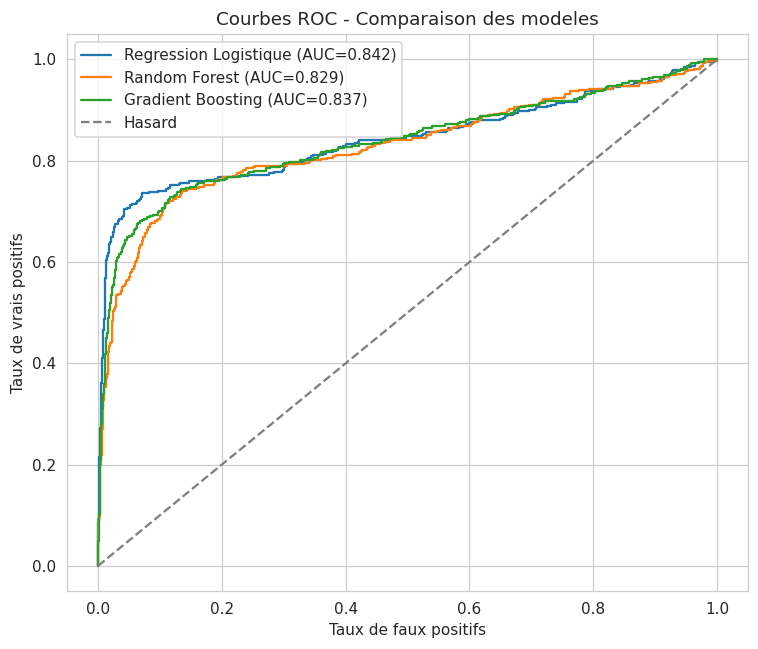

In [9]:
plt.figure(figsize=(7, 6))
for name, pipe in fitted_pipelines.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Hasard")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC - Comparaison des modeles")
plt.legend()
plt.tight_layout()
plt.savefig("fig_roc_curves.png", bbox_inches="tight")
plt.show()

## 5. Matrice de confusion du modèle retenu

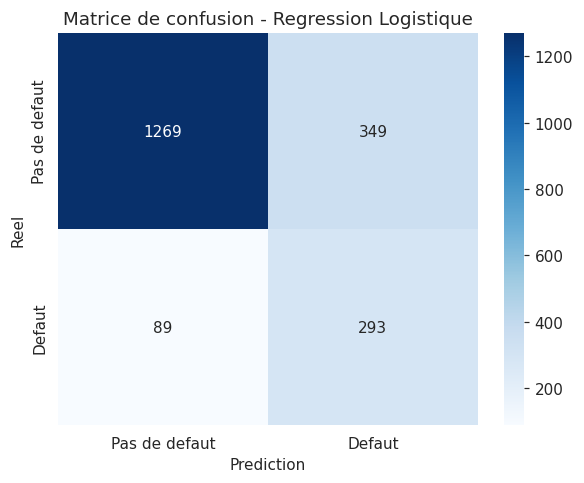

In [10]:
y_pred_best = best_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pas de defaut", "Defaut"], yticklabels=["Pas de defaut", "Defaut"])
plt.xlabel("Prediction")
plt.ylabel("Reel")
plt.title(f"Matrice de confusion - {best_model_name}")
plt.tight_layout()
plt.savefig("fig_confusion_matrix.png", bbox_inches="tight")
plt.show()

## 6. Importance des variables

Quels facteurs pèsent le plus dans la décision du modèle ?

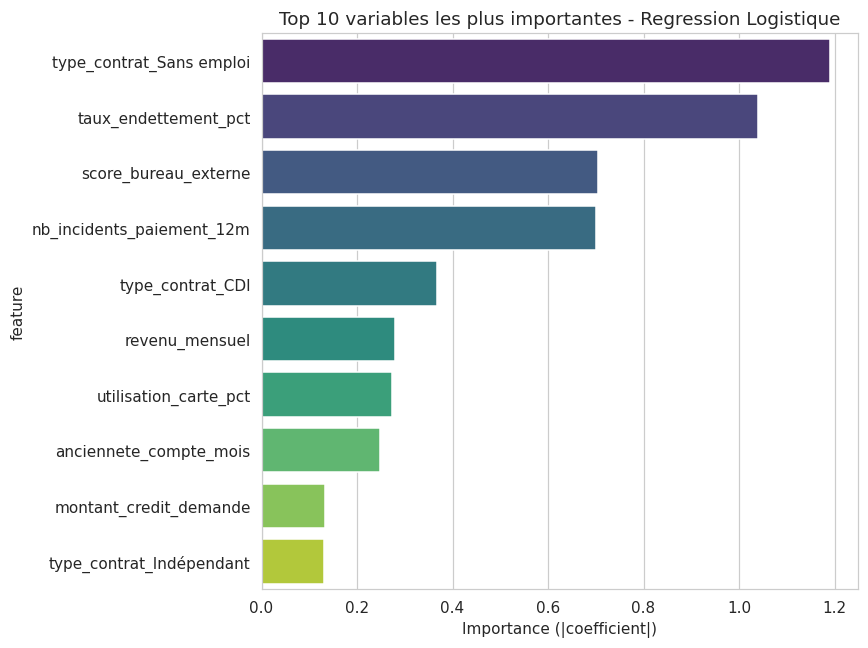

In [11]:
feature_names = (
    num_features
    + list(best_pipeline.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(cat_features))
)
model_step = best_pipeline.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    importances = model_step.feature_importances_
    imp_label = "Importance"
else:
    importances = np.abs(model_step.coef_[0])
    imp_label = "Importance (|coefficient|)"

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(data=imp_df, x="importance", y="feature", hue="feature", palette="viridis", legend=False)
plt.title(f"Top 10 variables les plus importantes - {best_model_name}")
plt.xlabel(imp_label)
plt.tight_layout()
plt.savefig("fig_feature_importance.png", bbox_inches="tight")
plt.show()

**Interprétation métier :** les variables les plus déterminantes sont le type de contrat (sans emploi notamment), le taux d'endettement, le score bureau externe et le nombre d'incidents de paiement passés — ce qui correspond aux facteurs de risque classiquement retenus dans les modèles de scoring crédit du secteur bancaire/fintech.


## 7. Export pour dashboard Power BI

On exporte les prédictions du modèle avec une segmentation en 3 niveaux de risque (Faible / Moyen / Élevé), directement exploitable pour construire un dashboard de pilotage à destination des équipes risque.


In [12]:
export_df = X_test.copy()
export_df["default_reel"] = y_test.values
export_df["proba_defaut"] = best_pipeline.predict_proba(X_test)[:, 1].round(4)
export_df["prediction"] = y_pred_best
export_df["segment_risque"] = pd.cut(
    export_df["proba_defaut"],
    bins=[0, 0.15, 0.35, 1.0],
    labels=["Faible risque", "Risque moyen", "Risque eleve"]
)
export_df.to_csv("export_powerbi_credit_scoring.csv", index=False)

print(export_df["segment_risque"].value_counts())
export_df.head()

segment_risque
Risque eleve     959
Risque moyen     546
Faible risque    495
Name: count, dtype: int64


,age,revenu_mensuel,anciennete_compte_mois,nb_transactions_mois,montant_moyen_transaction,taux_endettement_pct,nb_incidents_paiement_12m,montant_credit_demande,type_contrat,score_bureau_externe,utilisation_carte_pct,default_reel,proba_defaut,prediction,segment_risque
2496,32,925.82,27,13,145.19,21.86,0,5371.52,CDI,718,43.85,0,0.1265,0,Faible risque
5737,49,2988.84,53,19,62.37,18.79,1,1986.09,Sans emploi,649,61.36,0,0.5896,1,Risque eleve
7176,46,1913.45,27,11,64.95,3.05,0,9482.11,CDI,678,25.81,0,0.0379,0,Faible risque
914,34,1687.86,28,24,144.25,21.63,0,8131.31,Indépendant,457,21.82,0,0.5212,1,Risque eleve
361,50,2029.71,5,18,109.97,11.33,0,2016.15,CDI,725,36.71,0,0.0511,0,Faible risque


## Conclusion

- Modèle final retenu : **Régression Logistique**, AUC de test = **0.84** (AUC validation croisée 5-fold = 0.86)
- Les facteurs de risque identifiés sont cohérents avec les pratiques du secteur (endettement, historique de paiement, stabilité de l'emploi, score externe)
- Les prédictions sont exportées et segmentées en 3 niveaux de risque, prêtes à être intégrées dans un **dashboard Power BI** pour un pilotage opérationnel par les équipes risque/crédit

**Pistes d'amélioration possibles :** enrichissement avec des données comportementales supplémentaires (historique transactionnel détaillé), calibration du modèle (Platt scaling), test d'algorithmes de boosting plus poussés (XGBoost, LightGBM), et mise en place d'un seuil de décision ajusté au coût métier réel d'un faux négatif vs faux positif.
